In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
from google.colab import files
uploaded = files.upload()

Saving quebec_housing_sales_v2.csv to quebec_housing_sales_v2 (1).csv


In [32]:
filepath = '/content/quebec_housing_sales_v2.csv'
df = pd.read_csv(filepath)

In [33]:
df.head(10)

,property_id,city,neighborhood,property_type,bedrooms,bathrooms,living_area_sqft,lot_size_sqft,year_built,renovation_year,garage,basement,sale_year,sale_price
0,1,Châteauguay,Centre-Ville,Townhouse,3,2,1160,2304.0,2022,NaN,Yes,No,2024,326000
1,2,Trois-Rivières,Cap-de-la-Madeleine,Duplex,4,4,1807,5869.0,2006,2024.0,No,Yes,2025,444000
2,3,Lévis,Charny,Townhouse,3,1,803,3387.0,1989,NaN,Yes,Yes,2025,273000
3,4,Laval,Fabreville,Single Family,3,3,1083,11417.0,1972,2016.0,Yes,Yes,2023,465000
4,5,Longueuil,Greenfield Park,Condo,2,2,714,NaN,1997,2010.0,Yes,No,2022,371000
5,6,Victoriaville,Centre-Ville,Single Family,4,3,2081,5682.0,1967,NaN,Yes,Yes,2023,458000
6,7,Montréal,Outremont,Townhouse,3,3,1036,3343.0,1939,NaN,No,Yes,2023,383000
7,8,Sherbrooke,Lennoxville,Single Family,4,2,1767,4750.0,2007,NaN,Yes,Yes,2023,475000
8,9,Lévis,Saint-Nicolas,Townhouse,4,2,1178,2763.0,1956,2020.0,No,No,2024,337000
9,10,Saint-Jérôme,Bellefeuille,Bungalow,4,1,1063,5380.0,1984,NaN,Yes,Yes,2025,386000


In [34]:
df.shape

(5000, 14)

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   property_id       5000 non-null   int64  
 1   city              5000 non-null   object 
 2   neighborhood      5000 non-null   object 
 3   property_type     5000 non-null   object 
 4   bedrooms          5000 non-null   int64  
 5   bathrooms         5000 non-null   int64  
 6   living_area_sqft  5000 non-null   int64  
 7   lot_size_sqft     3789 non-null   float64
 8   year_built        5000 non-null   int64  
 9   renovation_year   1592 non-null   float64
 10  garage            5000 non-null   object 
 11  basement          5000 non-null   object 
 12  sale_year         5000 non-null   int64  
 13  sale_price        5000 non-null   int64  
dtypes: float64(2), int64(7), object(5)
memory usage: 547.0+ KB


In [36]:
df.describe()

,property_id,bedrooms,bathrooms,living_area_sqft,lot_size_sqft,year_built,renovation_year,sale_year,sale_price
count,5000.000000,5000.000000,5000.000000,5000.000000,3789.000000,5000.000000,1592.000000,5000.000000,5.000000e+03
mean,2500.500000,3.488200,2.325800,1313.693800,6257.154658,1983.074000,2015.054020,2023.411600,4.802140e+05
std,1443.520003,1.357435,0.968009,472.106052,2811.434500,26.483028,5.764461,1.332119,1.771254e+05
min,1.000000,1.000000,1.000000,469.000000,1570.000000,1900.000000,2005.000000,2021.000000,1.140000e+05
25%,1250.750000,2.000000,2.000000,915.000000,4086.000000,1966.000000,2010.000000,2022.000000,3.527500e+05
50%,2500.500000,3.000000,2.000000,1273.000000,5767.000000,1985.000000,2015.000000,2024.000000,4.530000e+05
75%,3750.250000,4.000000,3.000000,1650.000000,8005.000000,2004.000000,2020.000000,2025.000000,5.840000e+05
max,5000.000000,8.000000,6.000000,2967.000000,14834.000000,2023.000000,2025.000000,2025.000000,1.425000e+06


In [37]:
df.isnull().sum()

,0
property_id,0
city,0
neighborhood,0
property_type,0
bedrooms,0
bathrooms,0
living_area_sqft,0
lot_size_sqft,1211
year_built,0
renovation_year,3408


In [38]:
numerical = df.select_dtypes(include=np.number)
categorical = df.select_dtypes(exclude=np.number)

In [39]:
numerical.columns

Index(['property_id', 'bedrooms', 'bathrooms', 'living_area_sqft',
       'lot_size_sqft', 'year_built', 'renovation_year', 'sale_year',
       'sale_price'],
      dtype='object')

In [40]:
categorical.columns

Index(['city', 'neighborhood', 'property_type', 'garage', 'basement'], dtype='object')

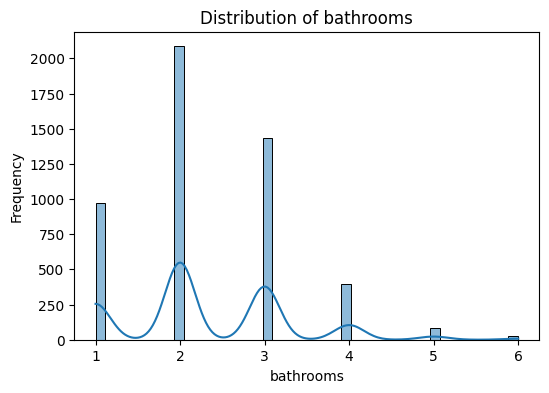

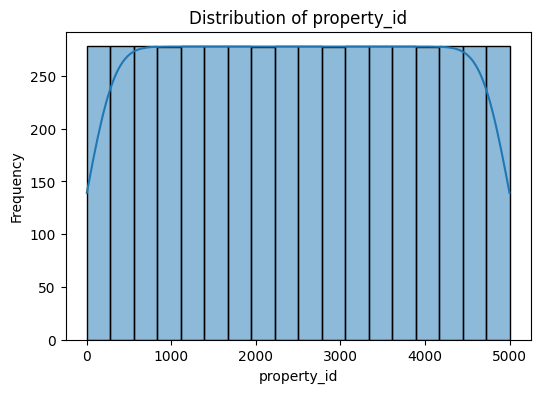

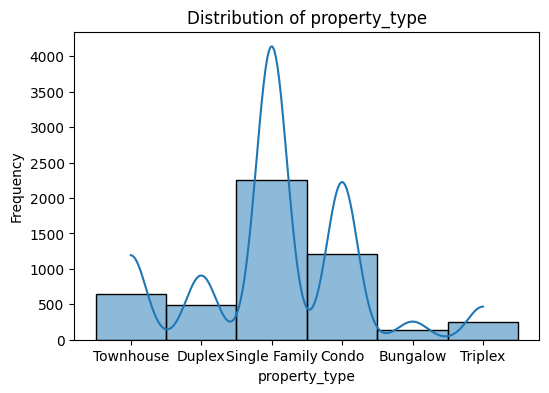

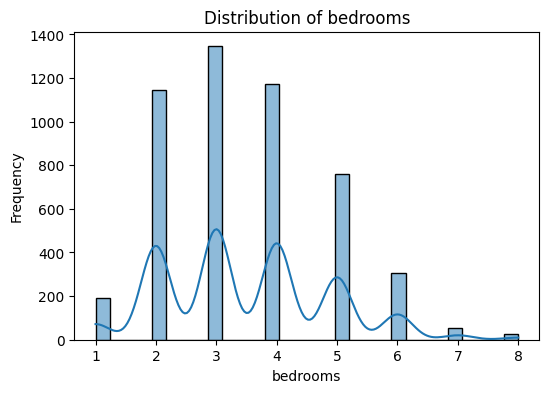

In [42]:
columns = ["bathrooms", "property_id", "property_type", "bedrooms"]

for col in columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

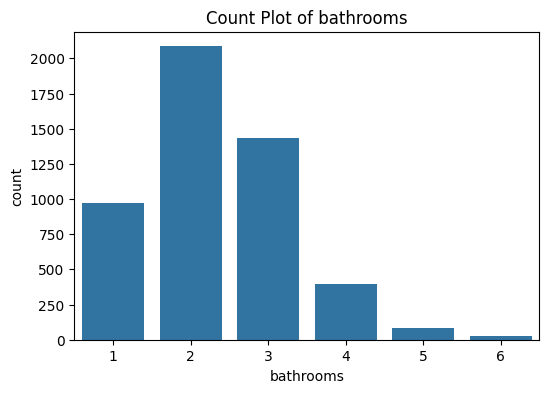

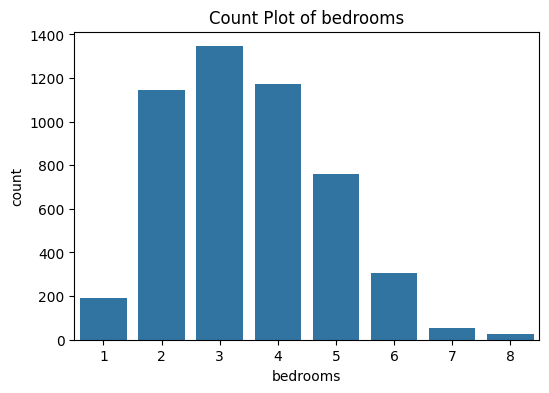

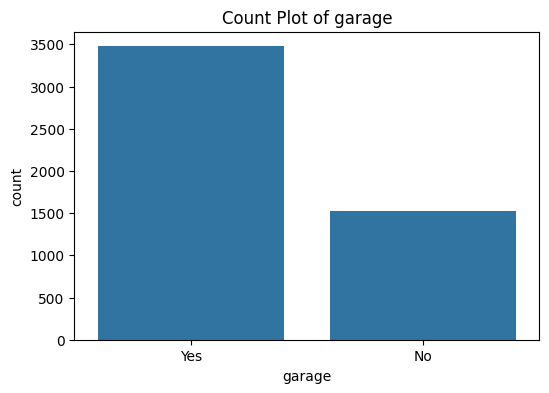

In [43]:
cat = ["bathrooms", "bedrooms", "garage"]

for col in cat:
    plt.figure(figsize=(6,4))
    sns.countplot(x=df[col])
    plt.title(f"Count Plot of {col}")
    plt.show()

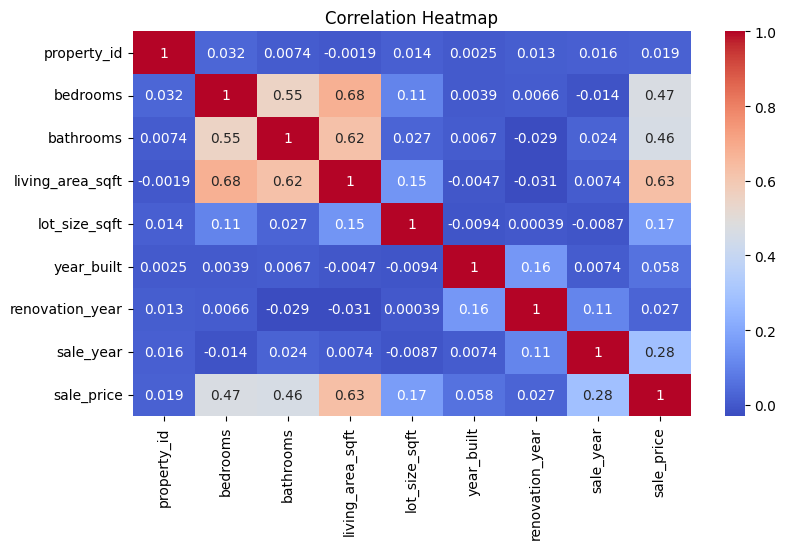

In [46]:
plt.figure(figsize=(9,5))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

In [48]:
df["sale_price"].mean()

np.float64(480214.0)

In [49]:
df["sale_price"].max()

1425000

In [50]:
df["sale_price"].min()

114000

In [51]:
df.groupby("property_id")["sale_price"].mean()

,sale_price
property_id,
1,326000.0
2,444000.0
3,273000.0
4,465000.0
5,371000.0
...,...
4996,406000.0
4997,198000.0
4998,680000.0


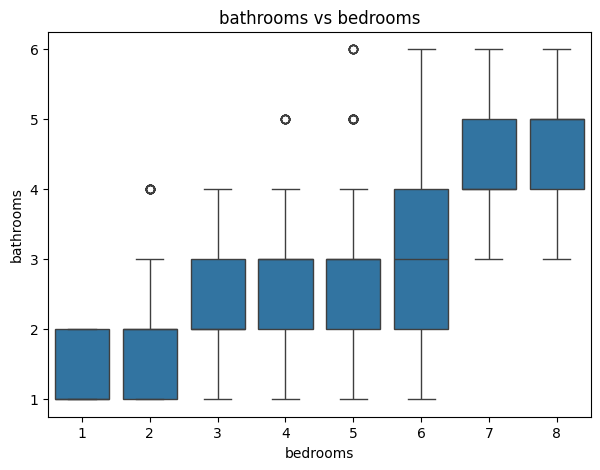

In [53]:
plt.figure(figsize=(7,5))

sns.boxplot(x="bedrooms", y="bathrooms", data=df)

plt.title("bathrooms vs bedrooms")

plt.show()

In [54]:
df["property_id"].mean()

np.float64(2500.5)

In [55]:
df["living_area_sqft"].mean()

np.float64(1313.6938)

In [56]:
df["sale_price"].value_counts()

,count
sale_price,
452000,22
472000,21
387000,21
318000,20
412000,20
...,...
913000,1
155000,1
864000,1


In [57]:
df.groupby("sale_price")["property_id"].mean()

,property_id
sale_price,
114000,2902.0
118000,1479.0
121000,1224.0
124000,1859.0
126000,2336.0
...,...
1342000,1373.0
1347000,355.0
1413000,1447.0
